# インド株 ファクター検証 — Step 7: 有意ファクターの時系列詳細

コア100本 + alt/AI 39本から **Q5（最上位分位）の超過リターンが有意**なファクターを選び、

- 分位ポートフォリオの累積超過リターン時系列（**中立化前 / 後**）
- IC の時系列（**中立化前 / 後**）

を1本ずつ出力する。図は `output/figures/07_significant/` に保存。

## 選定基準

$$\text{top\_t\_NW} \ge 2 \quad (\text{raw または size+sector 中立版のいずれかで})$$

- Q5 = スコア最上位分位の対ベンチマーク超過（EW）の Newey-West t 値
- **正の側のみ**（Q5 がプラスに有意）。ショート側だけ効くファクターは対象外
- 中立化 = Blom → セクターダミー + log(Cap) 回帰残差（Step 3 の規約）

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import factorlab as fl

fl.plotting.set_style()
pd.set_option("display.width", 250, "display.max_columns", 40, "display.float_format", lambda v: f"{v:,.3f}")

START, END = 200701, 202607
ALT_START = 201301
Q = 5
WEIGHTING = "ew"
TSTAT_MIN = 2.0
OUTDIR = "07_significant"

## 1. コア100本のスコアボード（raw / size+sector 中立）

In [2]:
style_map = fl.multi.load_style_map()
core_factors, core_groups = fl.multi.flatten_styles(style_map)

cpanel = fl.data.build_panel(core_factors, start=START, end=END)
cpanel, _ = fl.multi.build_scores(cpanel, core_factors, method="blom")
cpanel, _ = fl.multi.build_scores(cpanel, core_factors, method="blom",
                                  group_col="sector", control_cols=["log_cap"], suffix="_blom_ss")
core_raw_cols = {f: f"{f}_blom" for f in core_factors}
core_ss_cols = {f: f"{f}_blom_ss" for f in core_factors}

sb_c_raw, res_c_raw = fl.multi.factor_scoreboard(cpanel, core_raw_cols, groups=core_groups, q=Q, weighting=WEIGHTING)
sb_c_ss, res_c_ss = fl.multi.factor_scoreboard(cpanel, core_ss_cols, groups=core_groups, q=Q, weighting=WEIGHTING)
print("core done:", sb_c_raw.shape, sb_c_ss.shape)

core done: (100, 20) (100, 20)


## 2. alt / AI のスコアボード（raw / size+sector 中立）

In [3]:
apanel, inv = fl.altdata.build_alt_panel(start=ALT_START, end=END)
SHORT = {
    "controversy_score_ms": "contro_overall",
    "environment_controversy_score_ms": "contro_env",
    "customer_controversy_score_ms": "contro_customer",
    "governance_controversy_score_ms": "contro_gov",
    "labor_rights_controversy_score_ms": "contro_labor",
    "human_rights_controversy_score_ms": "contro_human",
    "nam_6_pillars_environment_global_issue_score": "esg_env_global",
    "nam_6_pillars_environment_global_issue_score_diff": "esg_env_global_diff",
    "nam_6_pillars_environment_social_stakeholder_score_342": "esg_env_stake_342",
    "nam_6_pillars_environment_social_stakeholder_score_343": "esg_env_stake_343",
    "nam_6_pillars_social_global_issue_score_diff": "esg_soc_global_diff",
    "nam_6_pillars_social_social_stakeholder_score": "esg_soc_stake",
    "nam_6_pillars_social_social_stakeholder_score_diff": "esg_soc_stake_diff",
    "nam_6_pillars_governance_score": "esg_gov",
    "nam_6_pillars_governance_score_diff": "esg_gov_diff",
    "nam_6_pillars_behavior_score": "esg_behavior",
    "nam_6_pillars_behavior_score_diff": "esg_behavior_diff",
    "nam_3_pillars_6_e_score": "esg_e_composite",
    "nam_3_pillars_6_s_score": "esg_s_composite",
    "nam_3_pillars_6_g_score": "esg_g_composite",
    "nam_1_pillars_3_esg_score": "esg_total",
}
apanel = apanel.rename(columns=SHORT)
inv["column"] = inv["column"].replace(SHORT)
ALT_COLS = list(inv["column"])
alt_groups = inv.set_index("column")["group"]

apanel, _ = fl.multi.build_scores(apanel, ALT_COLS, method="blom")
apanel, _ = fl.multi.build_scores(apanel, ALT_COLS, method="blom",
                                  group_col="sector", control_cols=["log_cap"], suffix="_blom_ss")
alt_raw_cols = {c: f"{c}_blom" for c in ALT_COLS}
alt_ss_cols = {c: f"{c}_blom_ss" for c in ALT_COLS}

sb_a_raw, res_a_raw = fl.multi.factor_scoreboard(apanel, alt_raw_cols, groups=alt_groups, q=Q,
                                                 weighting=WEIGHTING, min_universe=50)
sb_a_ss, res_a_ss = fl.multi.factor_scoreboard(apanel, alt_ss_cols, groups=alt_groups, q=Q,
                                               weighting=WEIGHTING, min_universe=50)
print("alt done:", sb_a_raw.shape, sb_a_ss.shape)

alt done: (37, 20) (37, 20)


## 3. 有意ファクターの選定

In [4]:
def select_significant(sb_raw, sb_ss, source):
    t_raw, t_ss = sb_raw["top_t_NW"], sb_ss["top_t_NW"]
    sel = (t_raw >= TSTAT_MIN) | (t_ss >= TSTAT_MIN)
    out = pd.DataFrame({
        "source": source,
        "style": sb_raw["style"],
        "top_raw": sb_raw["top_ann_excess"], "t_raw": t_raw,
        "top_ss": sb_ss["top_ann_excess"], "t_ss": t_ss,
        "sig_raw": t_raw >= TSTAT_MIN, "sig_ss": t_ss >= TSTAT_MIN,
    })
    return out[sel]


selected = pd.concat([
    select_significant(sb_c_raw, sb_c_ss, "core"),
    select_significant(sb_a_raw, sb_a_ss, "alt/ai"),
]).sort_values(["source", "top_ss"], ascending=[True, False])

print(f"選定: {len(selected)} 本（基準: Q{Q} の NW t >= {TSTAT_MIN}、raw または中立版）")
selected

選定: 17 本（基準: Q5 の NW t >= 2.0、raw または中立版）


,source,style,top_raw,t_raw,top_ss,t_ss,sig_raw,sig_ss
rev3p_gdb,alt/ai,Revision (GDB),0.074,2.655,0.078,2.769,True,True
rev3r_gdb,alt/ai,Revision (GDB),0.079,2.822,0.077,2.762,True,True
rev1r_gdb,alt/ai,Revision (GDB),0.080,2.917,0.075,2.858,True,True
rev1p_gdb,alt/ai,Revision (GDB),0.077,2.698,0.070,2.757,True,True
tvl,alt/ai,TVL,0.050,2.506,0.064,2.679,True,True
tvl_v3,alt/ai,TVL,0.030,1.687,0.056,2.397,False,True
ai,alt/ai,AI,0.076,4.040,0.050,2.553,True,True
esg_s_composite,alt/ai,NAM ESG,0.038,1.881,0.046,2.148,False,True
esg_behavior_diff,alt/ai,NAM ESG,0.048,2.428,0.042,1.724,True,False
rev3r,core,Momentum,0.099,4.528,0.095,3.938,True,True


## 4. 分位ポート時系列 & IC 時系列を一括出力

`output/figures/07_significant/{factor}__quantile_{raw|neutral}.png` /
`{factor}__ic_{raw|neutral}.png` に保存。

In [5]:
def render_factor(name, panel, res_raw, res_ss, col_raw, col_ss, label):
    figs = {}
    for tag, res, col in [("raw", res_raw, col_raw), ("neutral", res_ss, col_ss)]:
        vname = "raw" if tag == "raw" else "size+sector neutral"
        fig = fl.plotting.plot_quantile_timeseries(res, weighting=WEIGHTING, q=Q,
                                                   factor=f"{label} ({vname})")
        fl.plotting.savefig(fig, f"{OUTDIR}/{name}__quantile_{tag}")
        plt.close(fig)
        ic = fl.ic.information_coefficient(panel, col, "fwd_rtn", method="spearman")
        fig = fl.plotting.plot_ic(ic, ma_window=12, factor=f"{label} ({vname})", method="Spearman")
        fl.plotting.savefig(fig, f"{OUTDIR}/{name}__ic_{tag}")
        plt.close(fig)


for name, row in selected.iterrows():
    if row["source"] == "core":
        render_factor(name, cpanel, res_c_raw[name], res_c_ss[name],
                      core_raw_cols[name], core_ss_cols[name], f"{name} [{row['style']}]")
    else:
        render_factor(name, apanel, res_a_raw[name], res_a_ss[name],
                      alt_raw_cols[name], alt_ss_cols[name], f"{name} [{row['style']}]")

n_png = len(list((ROOT / "output" / "figures" / OUTDIR).glob("*.png")))
print(f"saved {n_png} figures -> output/figures/{OUTDIR}/")

saved 68 figures -> output/figures/07_significant/


## 5. 代表例のインライン表示（rev3r / ai / tvl）

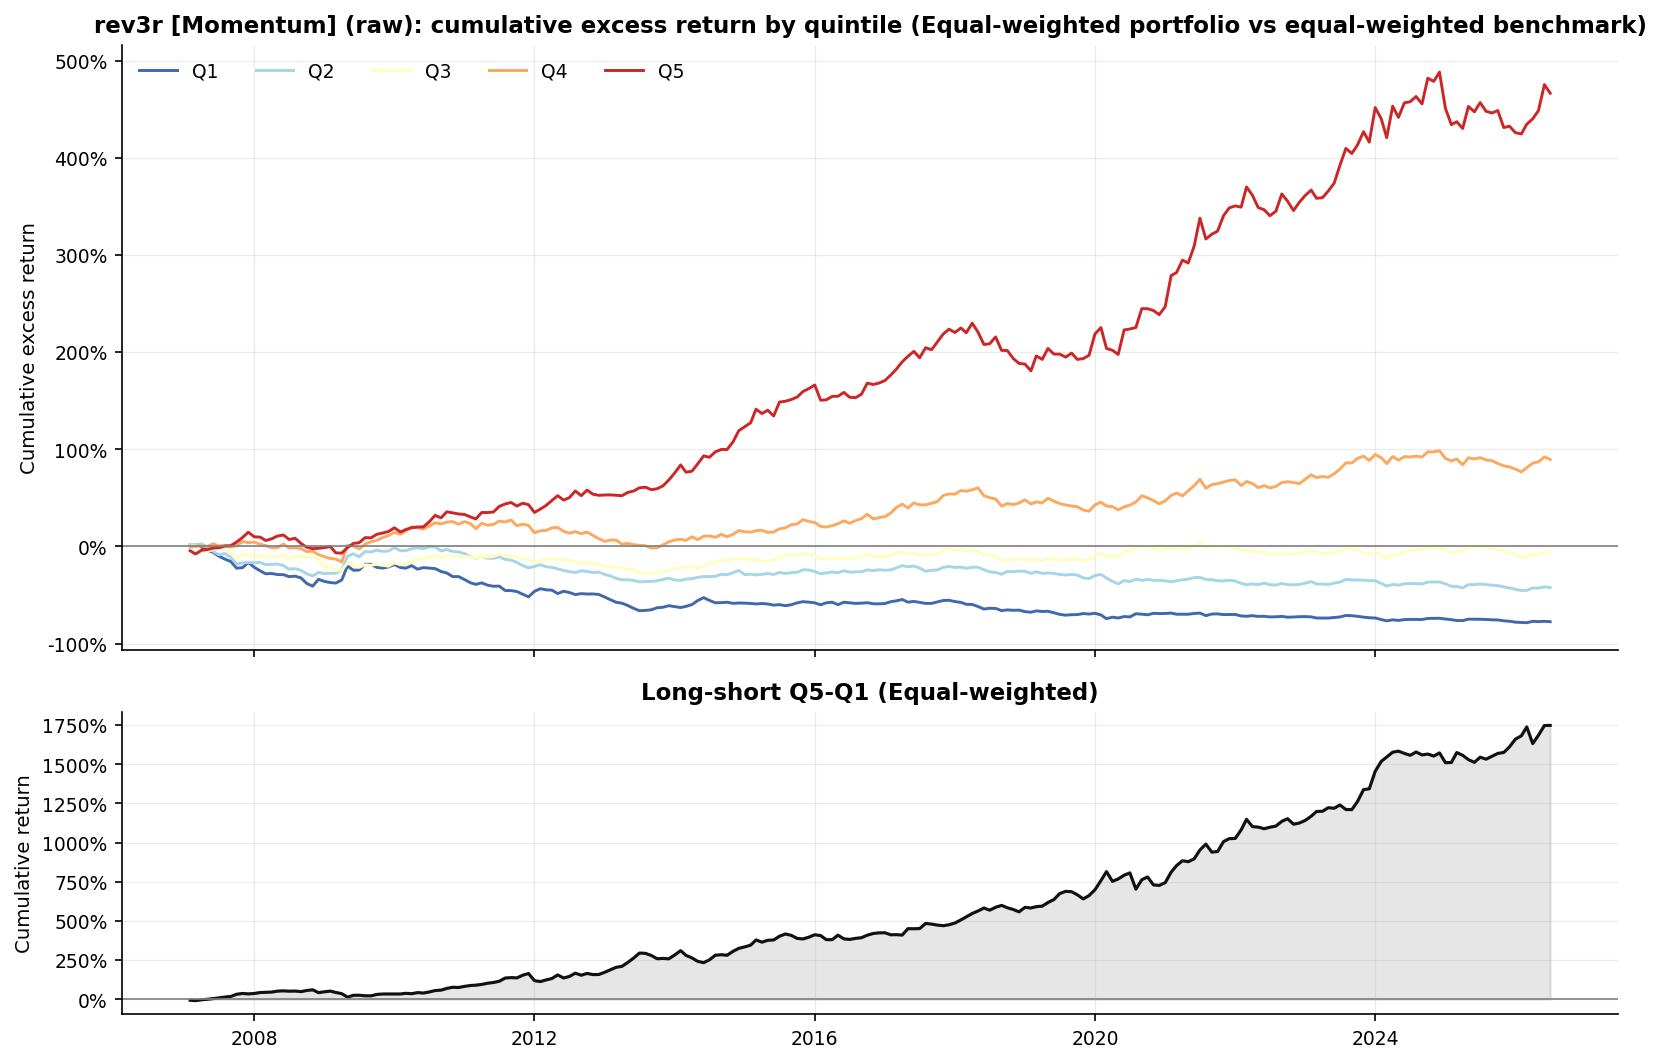

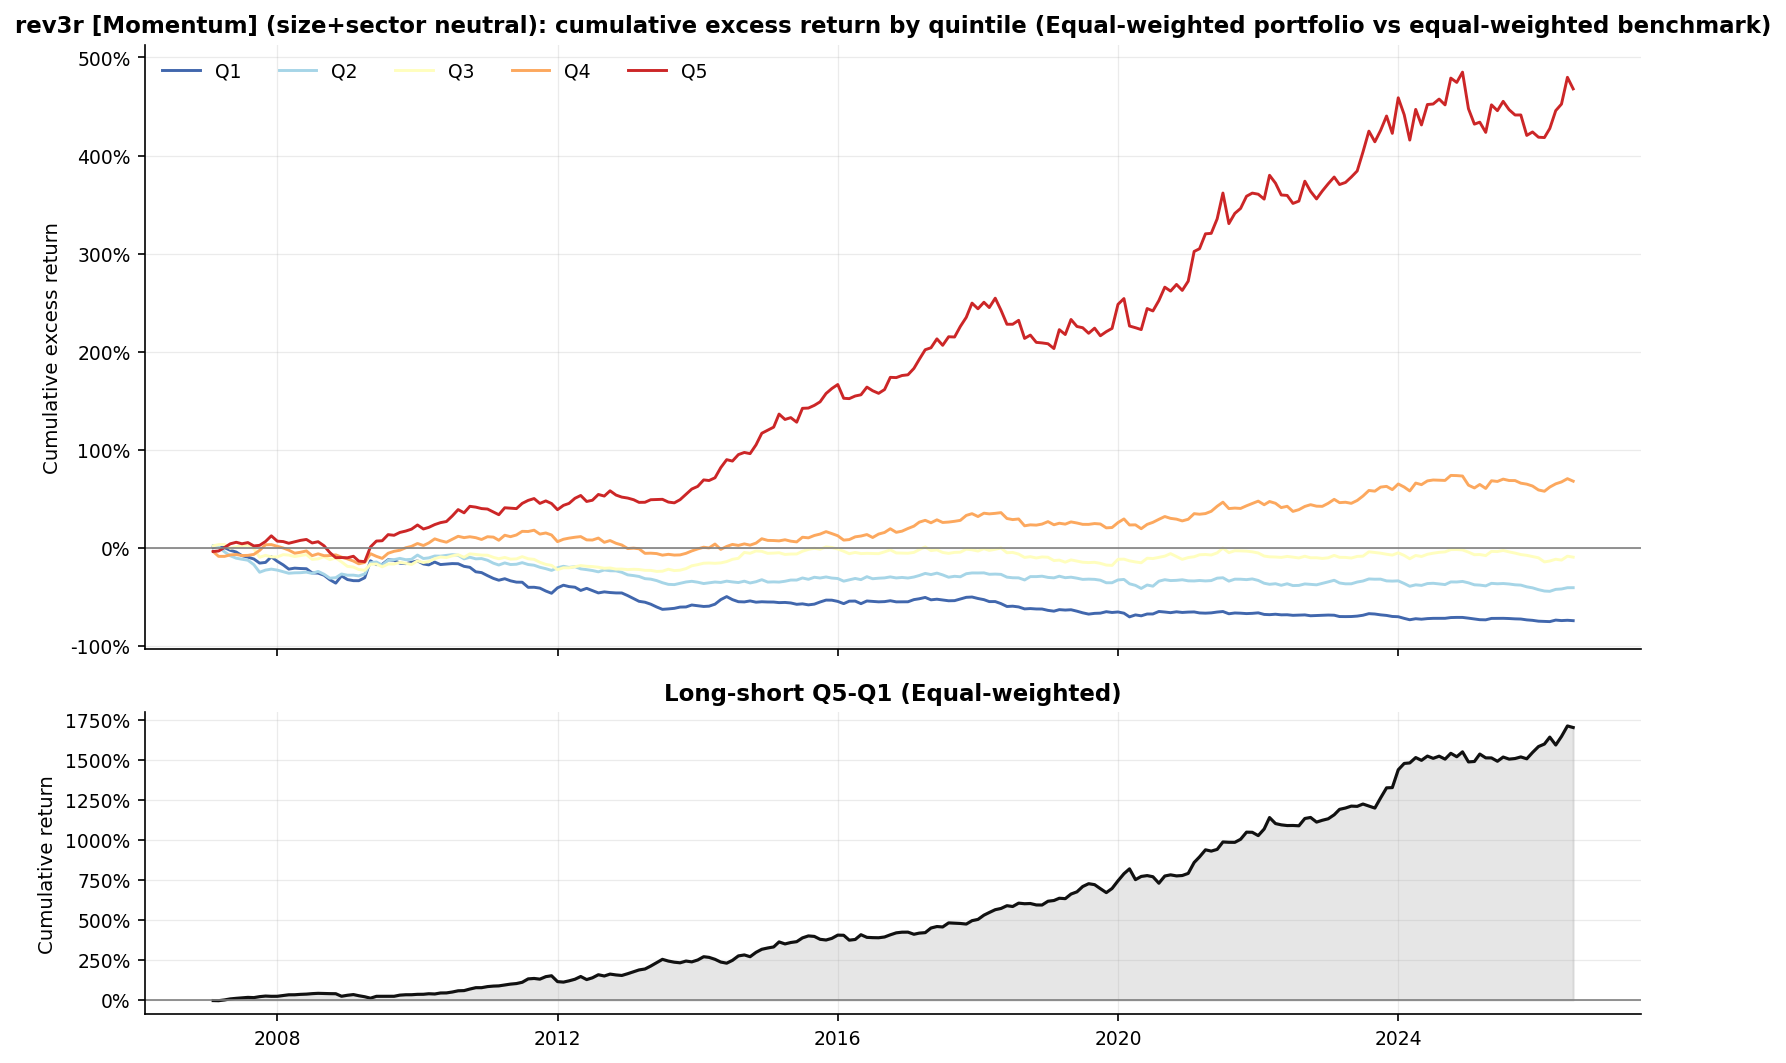

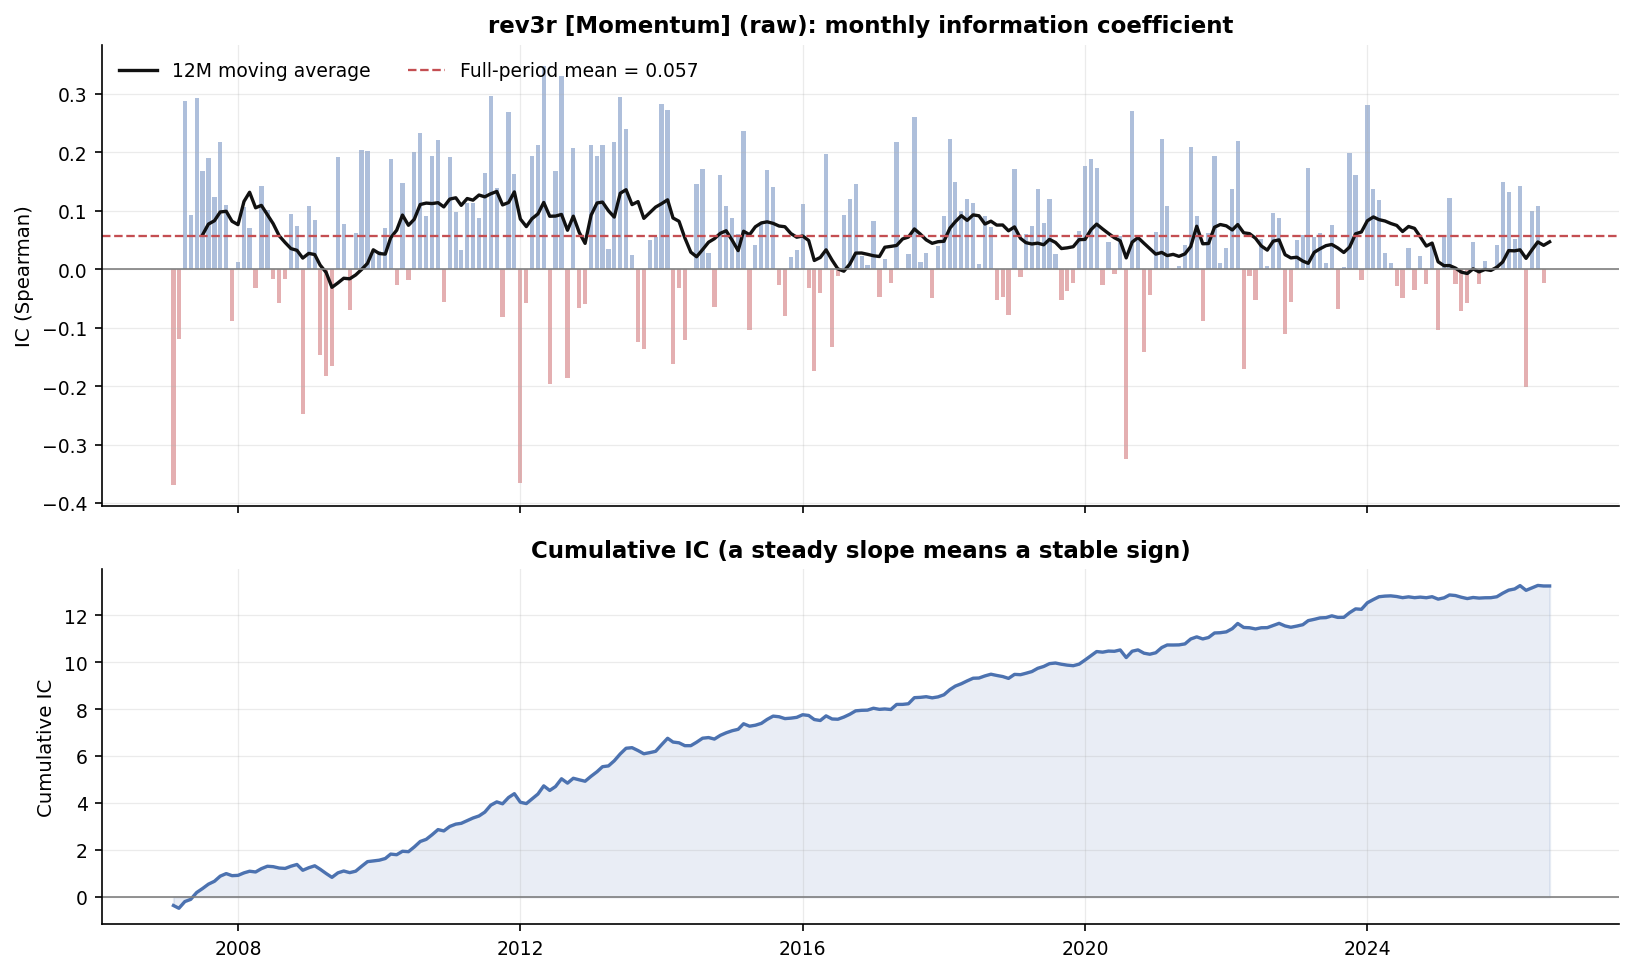

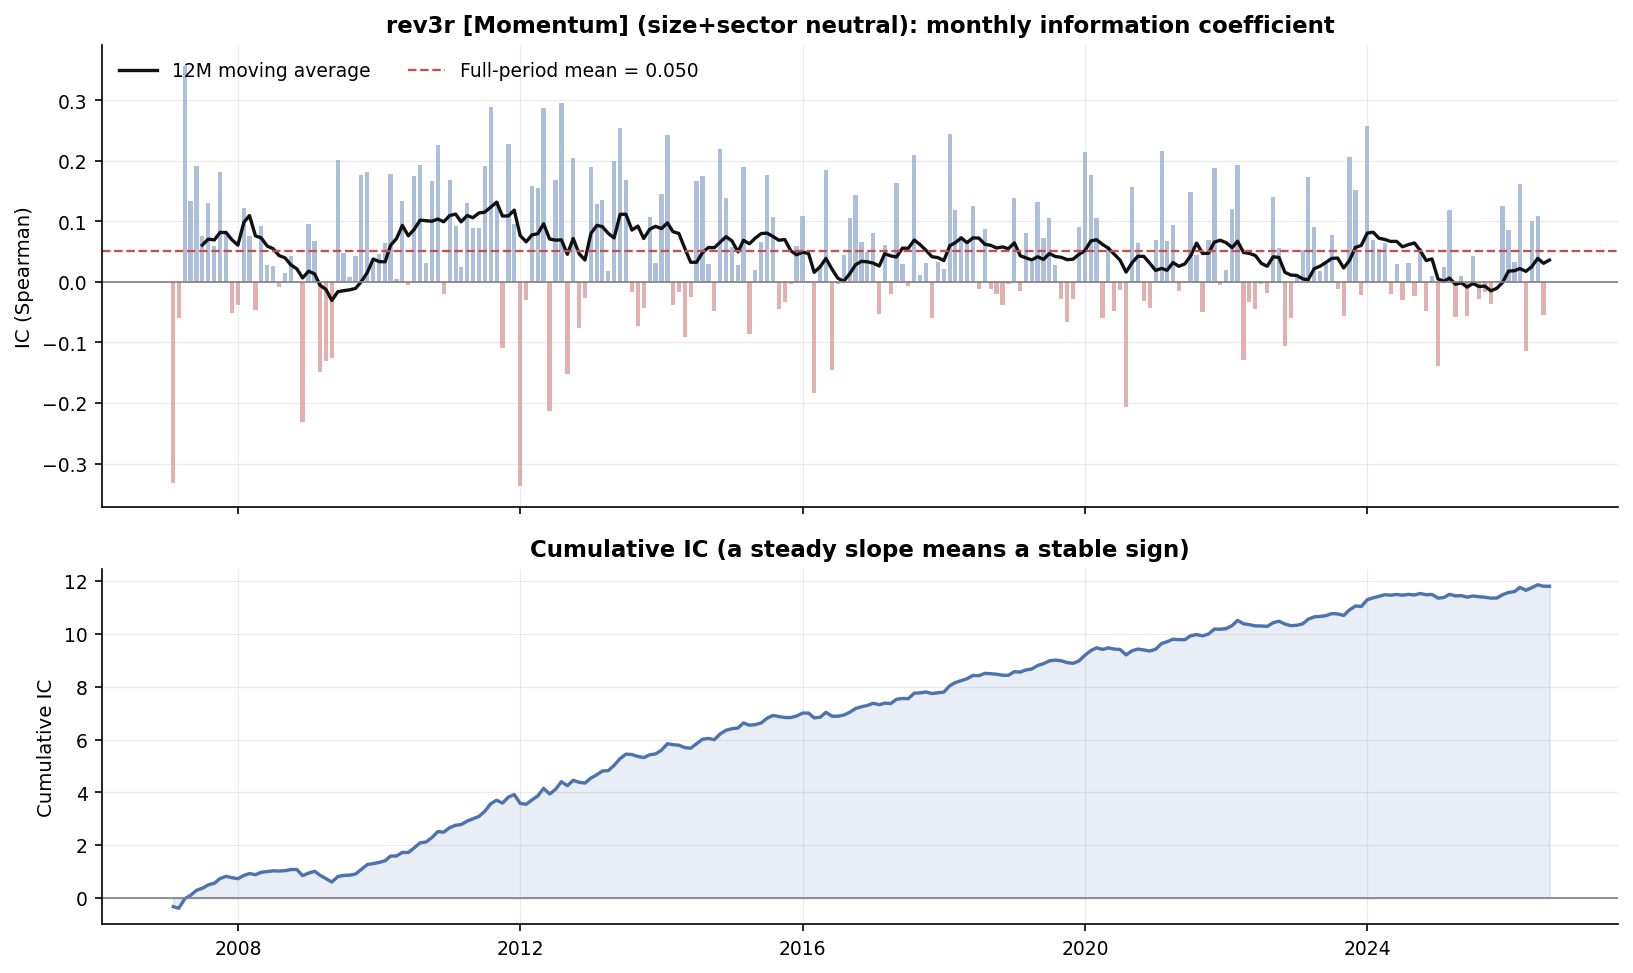

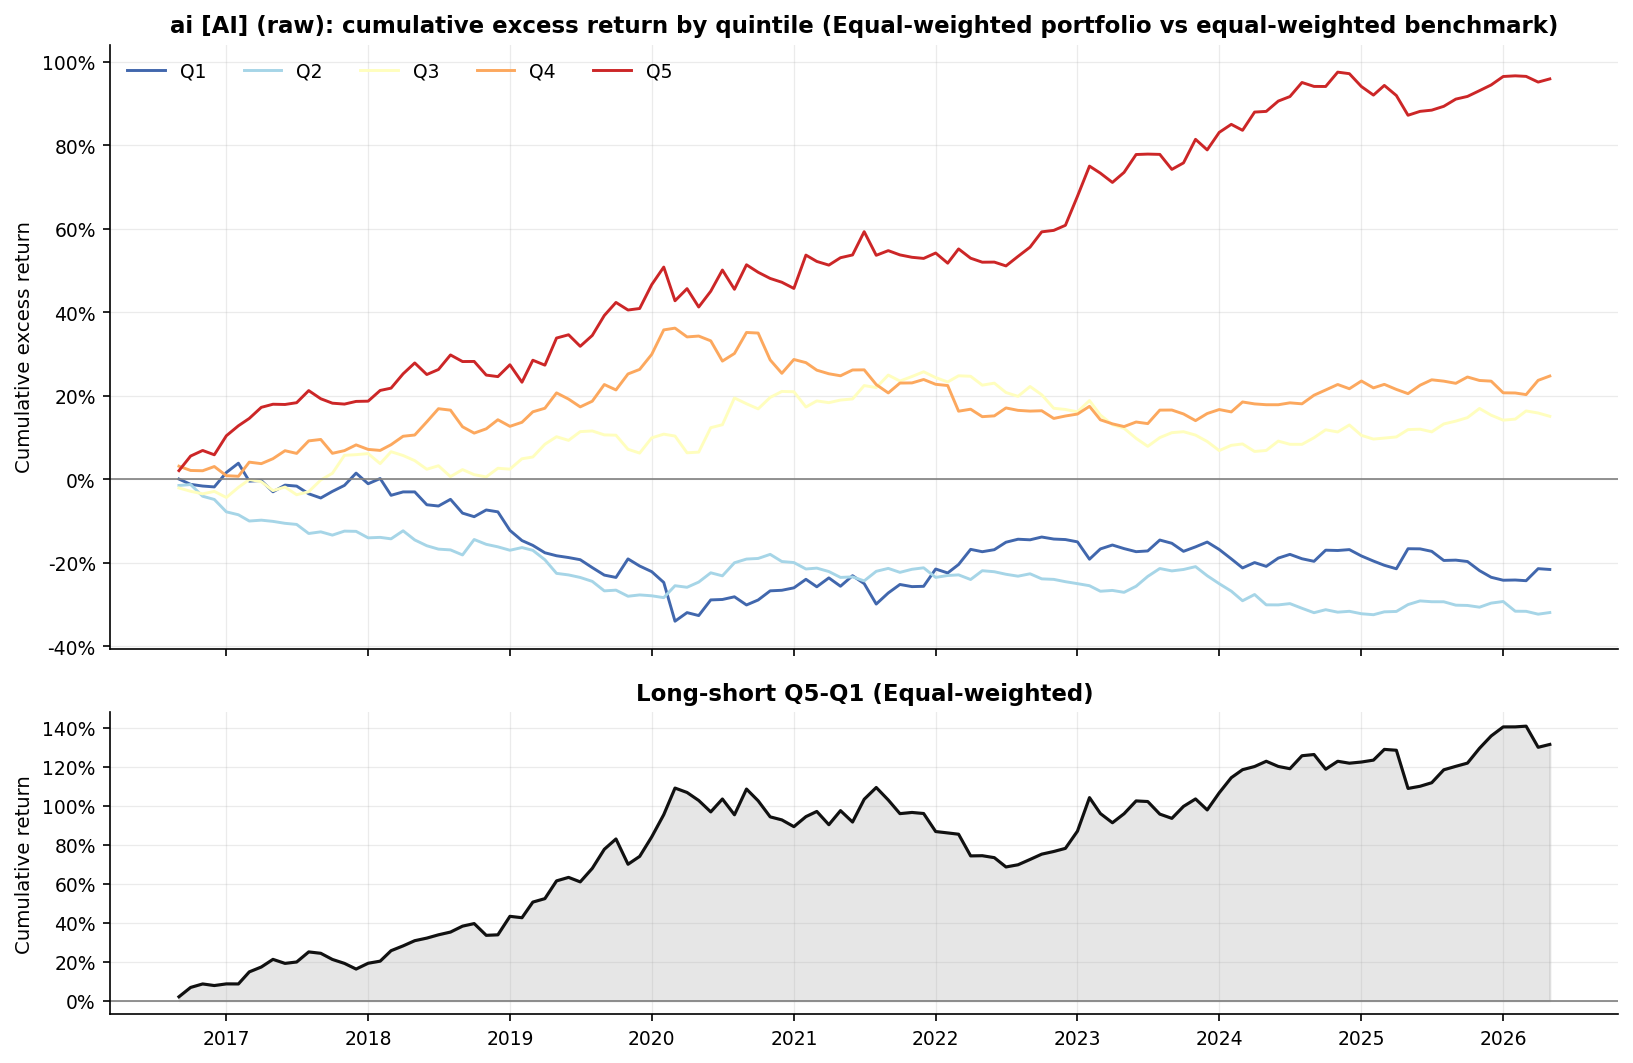

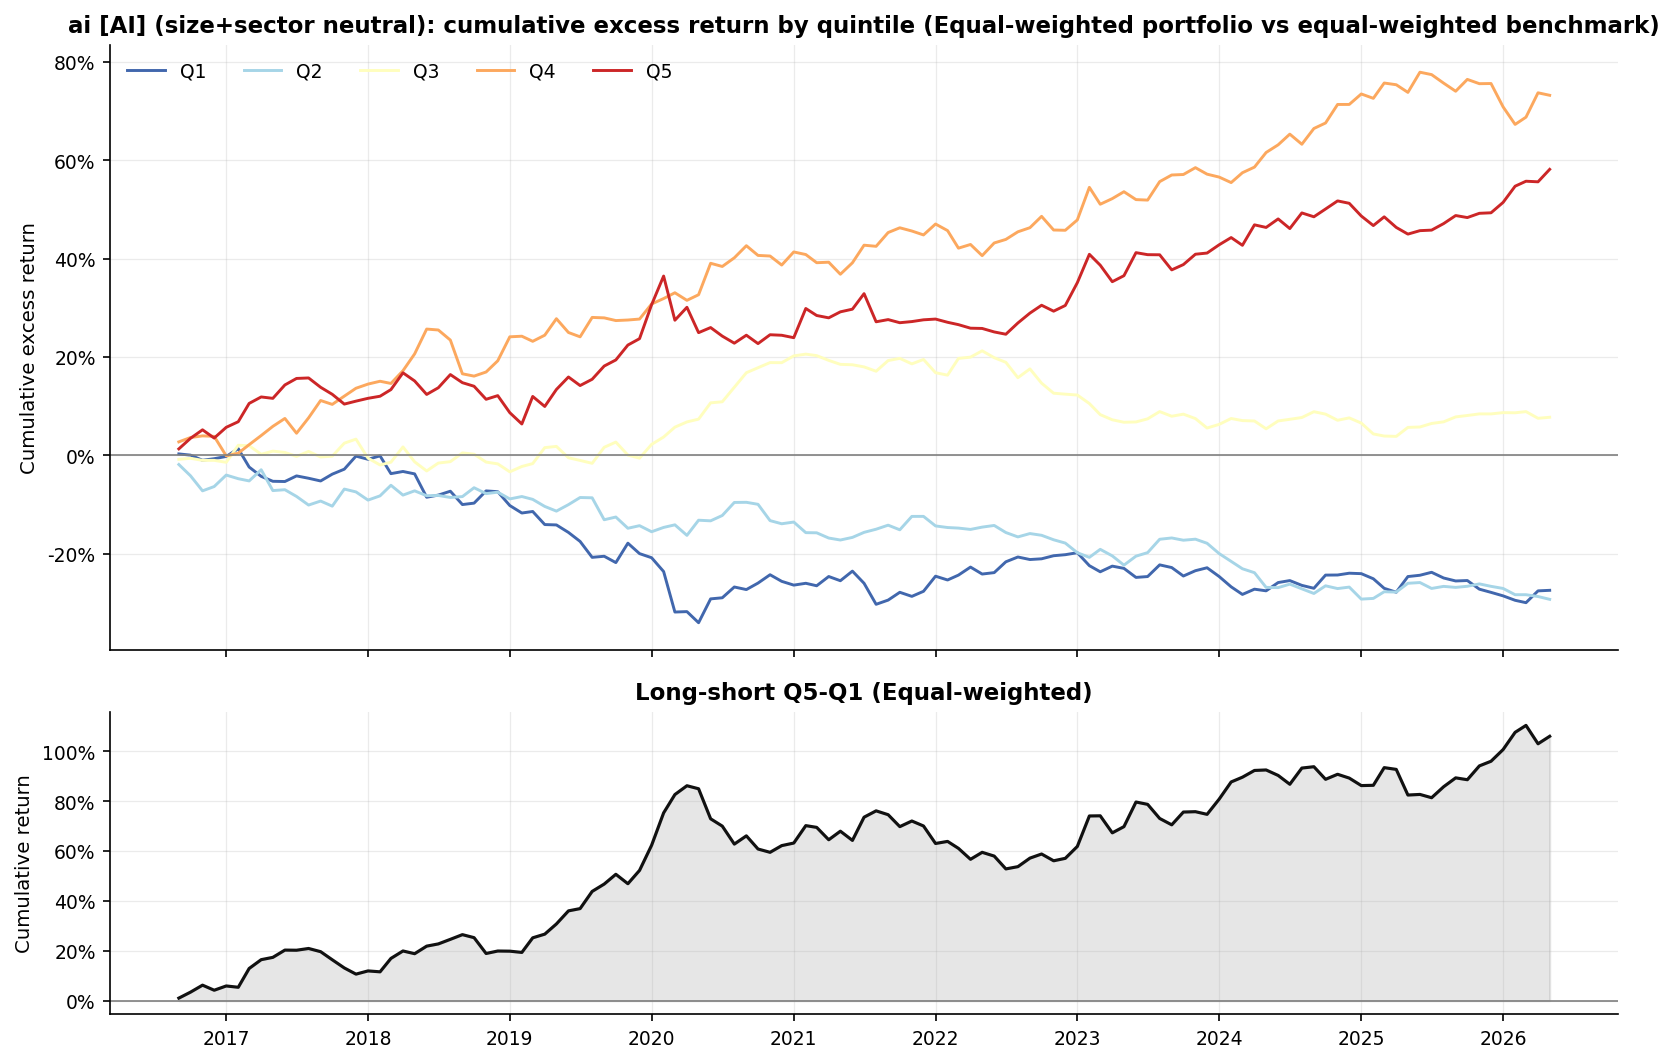

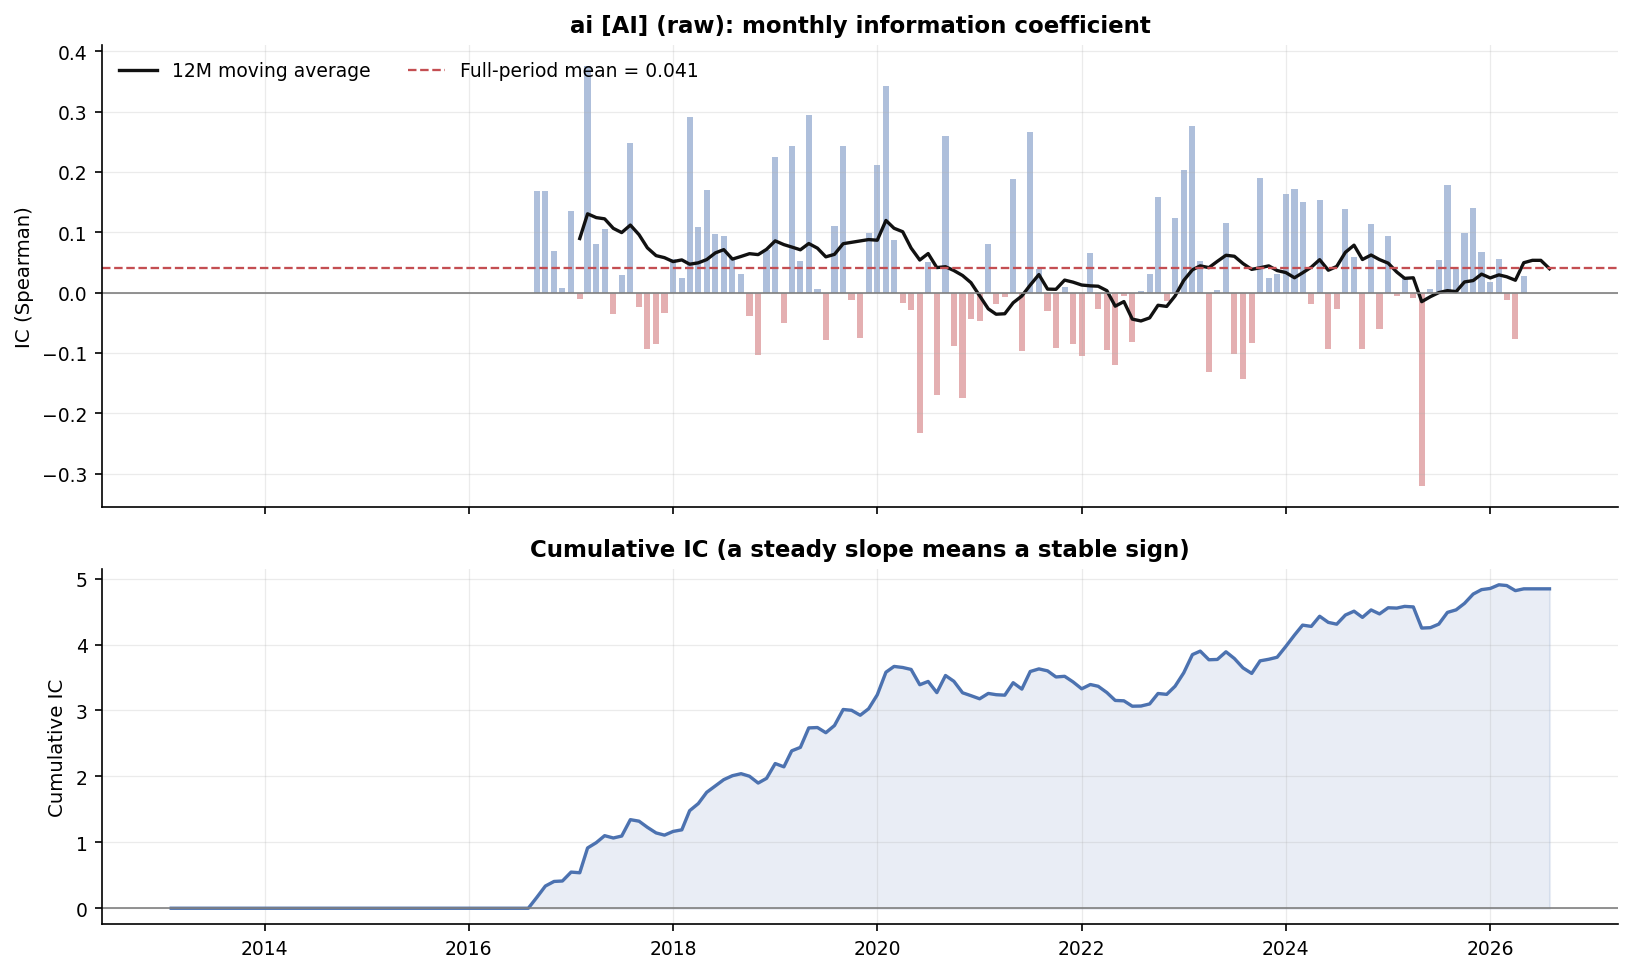

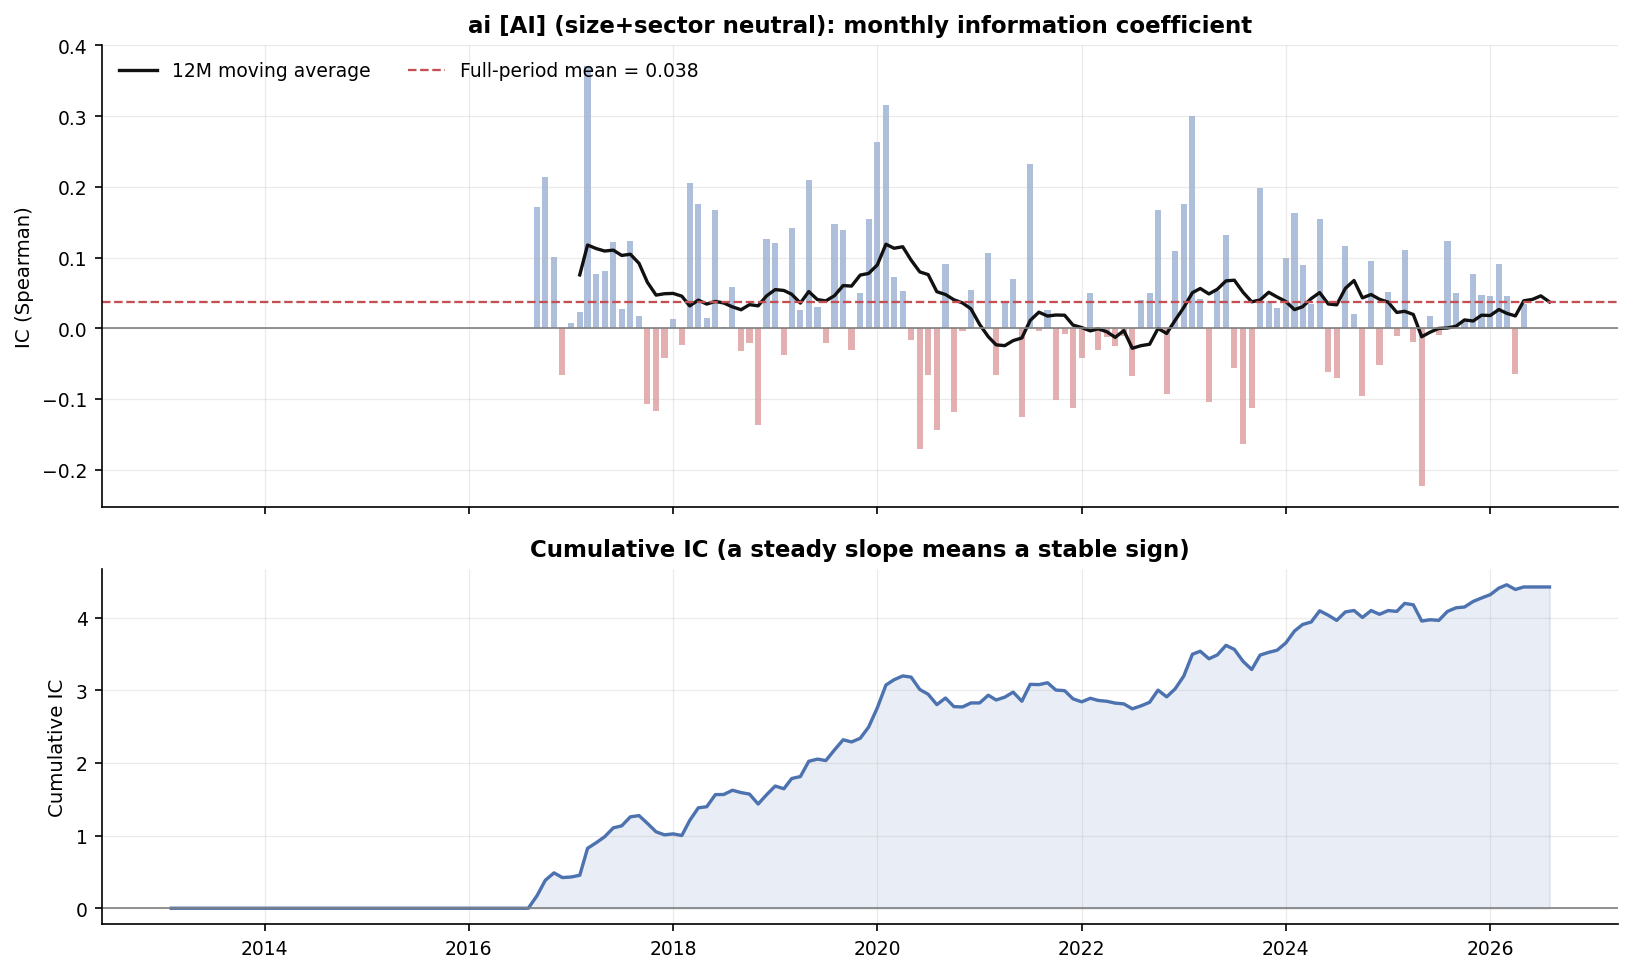

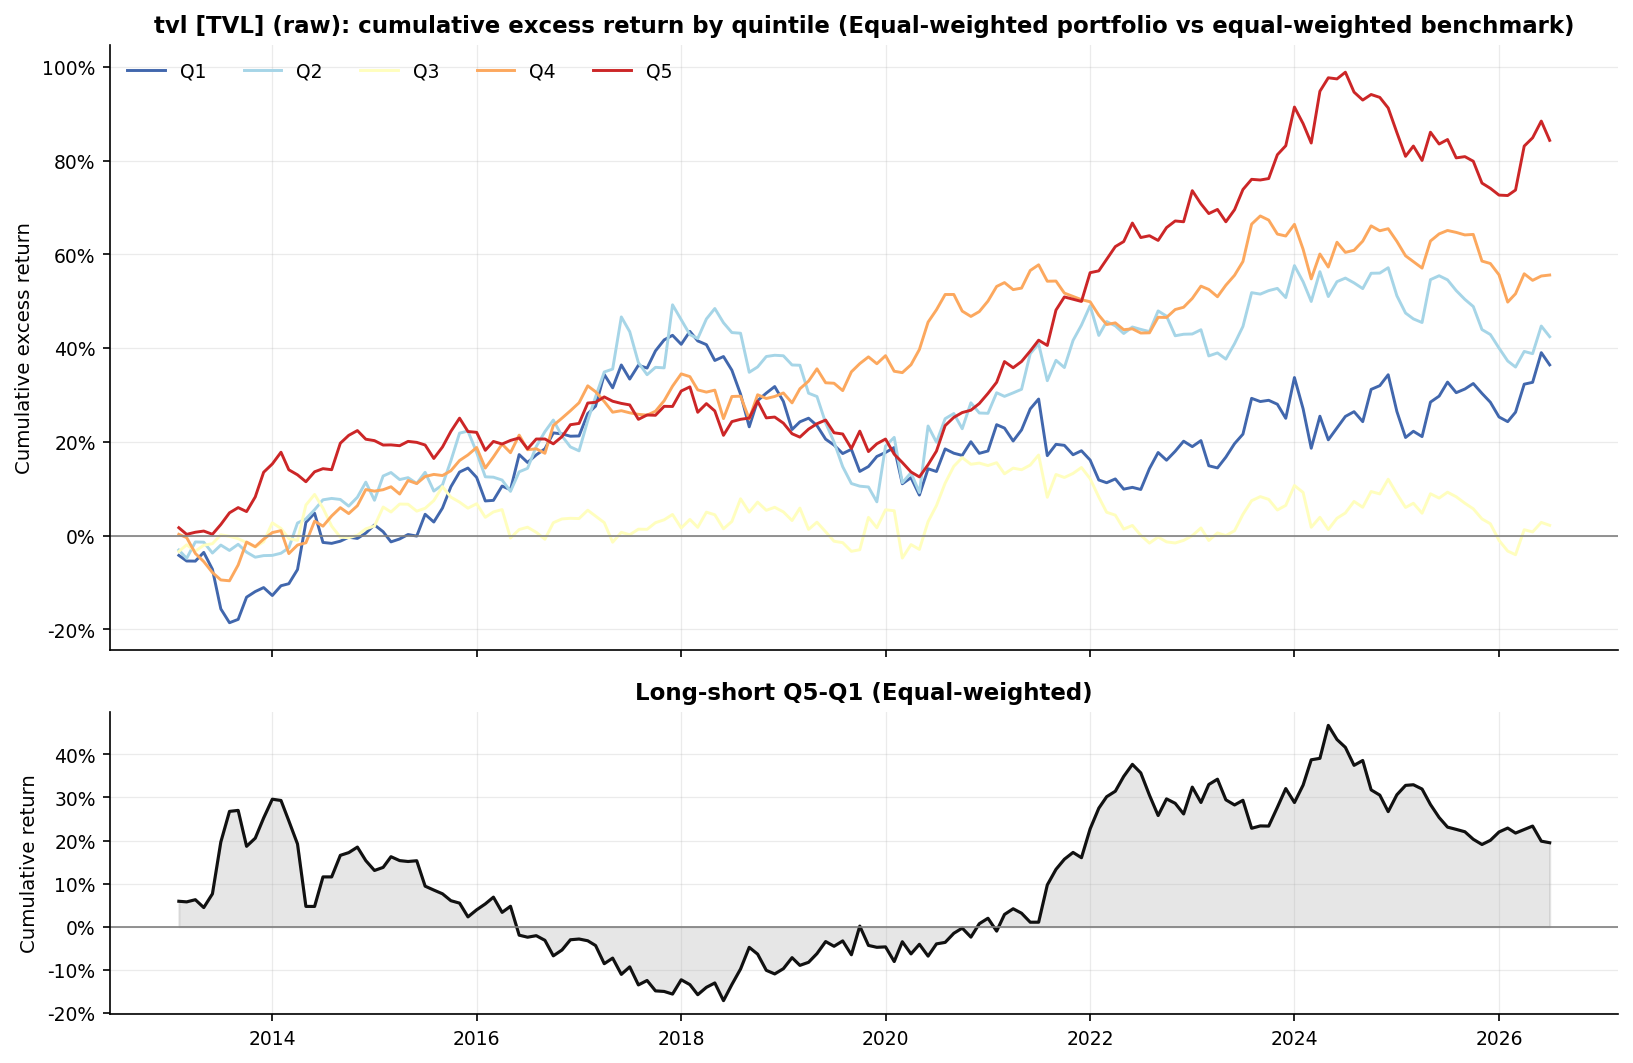

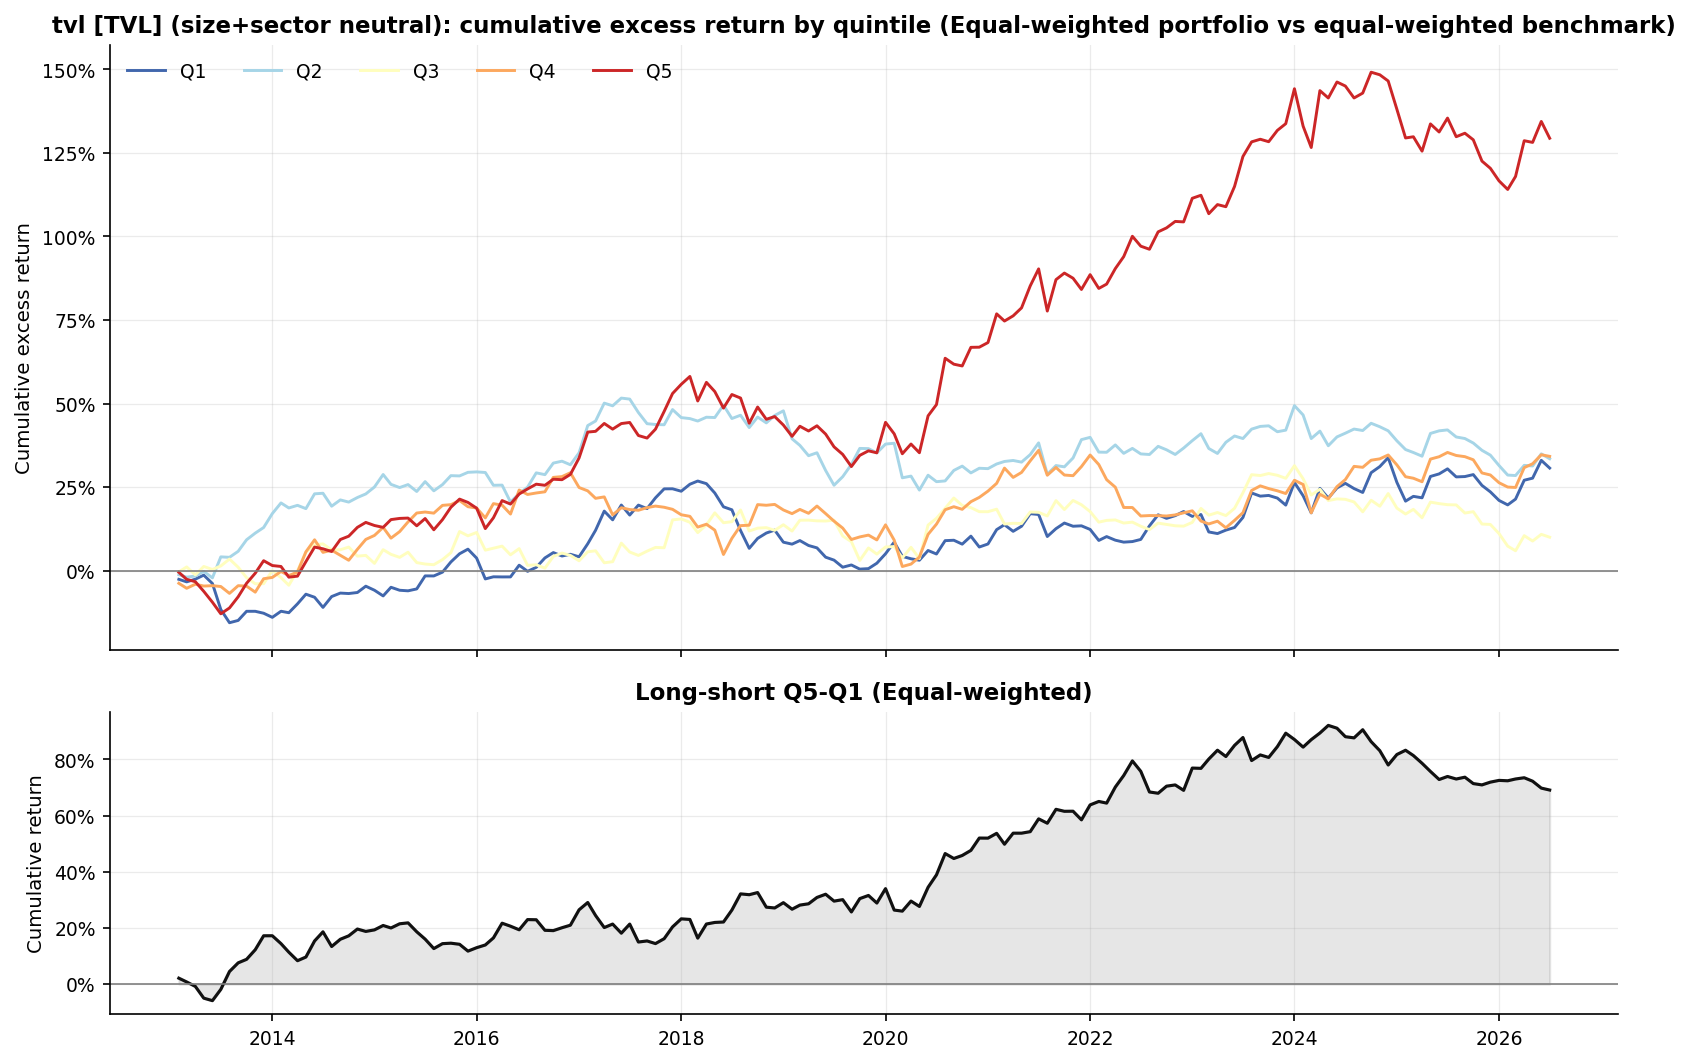

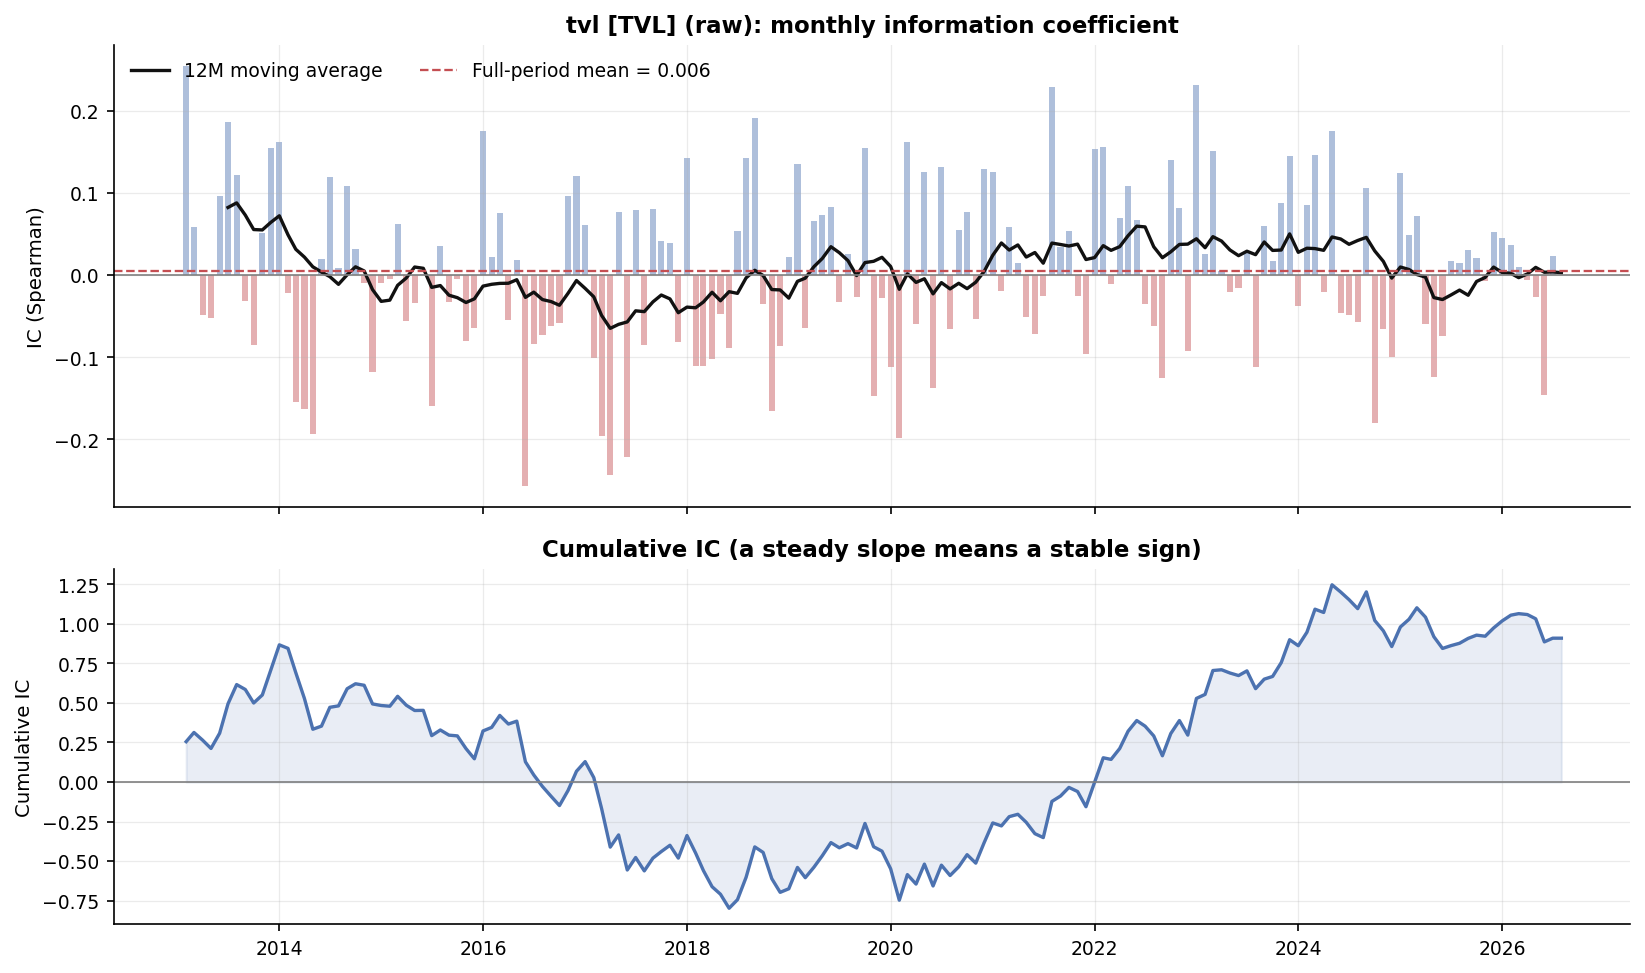

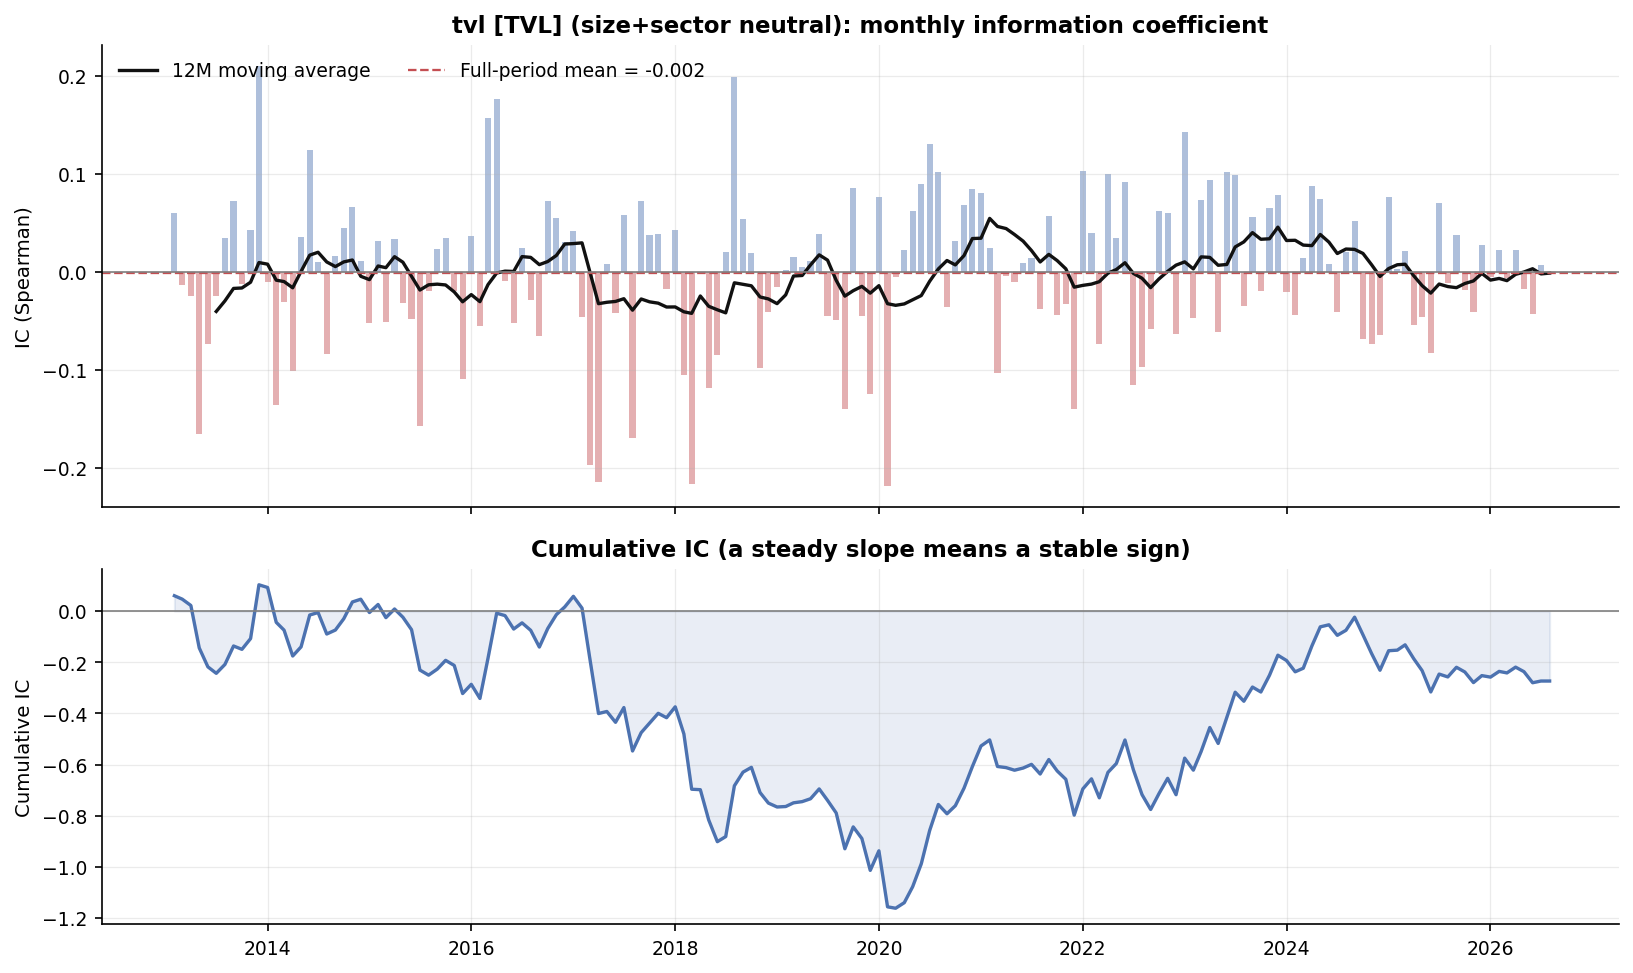

In [6]:
from IPython.display import Image, display

for name in ["rev3r", "ai", "tvl"]:
    if name not in selected.index:
        continue
    for kind in ["quantile", "ic"]:
        for tag in ["raw", "neutral"]:
            p = ROOT / "output" / "figures" / OUTDIR / f"{name}__{kind}_{tag}.png"
            if p.exists():
                display(Image(filename=str(p), width=900))

---

## 補足: 中立化後の時価総額ウェイト評価について

「スコアの中立化」と「ポートフォリオのウェイト」は別レイヤーの話:

- 中立化は**銘柄の並べ方**（どの銘柄を Q5 に入れるか）からサイズ・セクター情報を除く
- CW は**選んだ後の資金配分**。中立スコアで選んでも、CW にした瞬間に
  ポートフォリオ自体は大型に集中し、対ベンチのサイズ・セクター露出が復活する

したがって「中立化 × CW」は *純粋なシグナル評価としては一貫しない* が、
**実装可能性（キャパシティ）の検査としては意味がある**:
「サイズで選んでいないシグナルを、資金が実際に置ける場所（大型）に置いたら残るか」。

純粋に「大型でも効くか」を見たいなら、CW にするよりも
**ユニバースをベンチマーク銘柄（size 1-2）に絞って EW で評価**する方が
シグナルの検定として素直（ウェイトの歪みが混ざらない）。